# ICT-40b — Cognition analogique : les ondes cérébrales comme substrat de calcul (Miller-Brincat-Roy 2026)

*[Série ICT — Integrated Causal Trajectories, Epic #4588.](./README.md) Grain autonome — distillation externe, CPU uniquement. See #16550.*

> **Préprint, non relu.** Ce notebook distille *Analog Cognition and Consciousness* — Earl K. Miller, Scott L. Brincat, Jefferson E. Roy (MIT, Picower Institute), PsyArXiv **z48x7_v3**, publié le 2026-07-07 (CC-BY, PDF archivé dans la bibliographie du cours). Le papier pose une thèse hybride **spikes/ondes** : les synapses stockent l'information, mais le contrôle cognitif top-down et la conscience émergent des **champs électriques rythmiques** (ondes cérébrales), qui modulent l'excitabilité par couplage éphaptique et **calculent en analogique** par superposition. Ici, nous ne testons ni ne prouvons ces thèses : nous **opérationnalisons leurs quatre mécanismes** en monde jouet numpy et mesurons s'ils tiennent leurs promesses locales — la discipline de distillation de la série ([ICT-36](ICT-36-FLens-FactoredGeometry.ipynb), ICT-17b).

**Les quatre mécanismes du papier, et ce que ce notebook en fait :**

| Mécanisme (section du papier) | Affirmation | Banc jouet | Mesure |
|---|---|---|---|
| Couplage éphaptique (§ *Brain waves directly influence activity*) | Un champ faible module le tir de neurones proches du seuil | Sigmoïde au seuil + champ cosinusoïdal | Probabilité de spike vs phase du champ |
| Spatial Computing (§ *Spatial Computing*, Lundqvist et al. 2023) | Un stencil inhibiteur alpha/bêta sculpte où le feedforward s'exprime | Grille de voxels à connectivité chevauchante × 2 stencils | Sélectivité mixte émergente, angle de sous-espace |
| Calcul analogique (§ *Analog computation with waves*, Fig. 6-7) | La somme des ondes de contexte code chaque combinaison, sans re-câblage | Somme de stencils rectifiés 2 contextes × 2 modes | Matrice de distances des 4 combinaisons, effet d'interaction |
| Onde voyageuse (§ *Traveling waves*, Fig. 5) | Le balayage d'une onde instancie la transition entre sous-espaces de codage | Front voyageur interpolant deux stencils | Trajectoire PCA, angle principal avant/après |

Un cinquième banc (anesthésie) confronte le régime organisé à un régime lent désaligné et mesure l'effondrement de la cohérence inter-régionale — l'argument convergence du papier (des anesthésiques à cibles moléculaires différentes produisent le même tableau d'ondes lentes désynchronisées, Bardon et al. 2025 ; Eisen et al. 2026).

## Garde-fous d'honnêteté (à lire avant les chiffres)

Ces garde-fous conditionnent la lecture de chaque valeur mesurée ci-dessous ; ils prolongent ceux du [cadrage ICT-0](ICT-0-Framing.md).

1. **Monde jouet ≠ cerveau.** Une grille 48×96 de voxels, des sigmoïdes au seuil, des ondes planes cosinusoïdales : nous fabriquons le *mécanisme minimal* dont parle le papier, pas une simulation biophysique. Aucun chiffre ici n'est une grandeur neurale.
2. **On mesure des mécanismes, pas la conscience.** Le notebook vérifie que le gating par phase existe, que la superposition sépare les combinaisons, qu'une onde voyageuse déplace la population d'un sous-espace à l'autre. La thèse de conscience du papier reste hors de portée d'un toyet — et le notebook ne prétend pas la tester.
3. **Préprint non relu.** z48x7_v3 est un preprint de juillet 2026 ; les résultats empiriques cités (Chen et al. 2026, Rigotti et al. 2013, Davis et al. 2020...) sont ceux que le papier rapporte — non revérifiés ici.
4. **Proxys assumés.** PLV (valeur de verrouillage de phase) et angle principal sont des instruments de banc. Le pont vers $\Phi$ ([ICT-15](ICT-15-IntegratedComplexity.ipynb)) est **qualitatif** : il relie deux littératures, il ne calcule pas d'information intégrée.
5. **Déterminisme complet.** Toutes les expériences sont semées ; relancer ce notebook redonne exactement les mêmes chiffres.
6. **Ce qui réfuterait chaque banc.** Gating plat à champ fort (§2) ; sélectivité d'objet inchangée entre stencils (§3) ; 4 combinaisons confondues (§4) ; trajectoire sans transition (§5) ; PLV intact sous régime anesthésique (§6). Chaque section affiche la valeur qui aurait pu dire non.

## 1. Le problème de contrôle : pourquoi des synapses seules ne suffisent pas

Le point de départ du papier est un argument de **complexité du contrôle**. La cognition dirigée vers un but exige de coordonner des centaines de millions de neurones en une fraction de seconde. Un contrôleur purement synaptique devrait « savoir » quels neurones et quelles synapses encodent chaque représentation pour les sélectionner — une charge computationnelle invraisemblable.

L'observation qui contraint encore plus fort le cadre connexionniste classique : les neurones corticaux sont **multifonctionnels**. Environ un tiers des neurones préfrontaux s'engagent dans une tâche donnée, et beaucoup mélangent de façon *non linéaire* stimulus et contexte (*mixed selectivity*, Rigotti et al. 2013 ; Warden & Miller 2007) : un neurone peut répondre à l'objet A quand il est premier dans la séquence, et à l'objet B quand il est second. La flexibilité cognitive est là — mais le **routage** d'un réseau aussi chevauchant exige un mécanisme de contrôle qui ne passe pas par la re-configuration des poids.

La proposition du papier : les **ondes** fournissent ce niveau de contrôle intermédiaire (mésoéchelle) — plus lisses, plus basse-dimensionnelles que le circuit synaptique complet, et capables d'influencer l'excitabilité **sans synapse** (couplage éphaptique). Nous construisons d'abord le substrat : des cartes de poids chevauchantes, où chaque voxel reçoit des connexions pour plusieurs « objets » — la précondition anatomique de la sélectivité mixte.

In [1]:
import os
import sys

sys.path.insert(0, os.getcwd())  # convention de la série : cwd = ICT-Series/

import numpy as np
import matplotlib.pyplot as plt

from ict import analog_waves as aw

SEED = 20260918
print("numpy", np.__version__, "| ict.analog_waves OK (cwd :", os.path.basename(os.getcwd()) + ")")

numpy 2.3.5 | ict.analog_waves OK (cwd : ICT-Series)


## 2. Le substrat : connectivité chevauchante (précondition de la mixité)

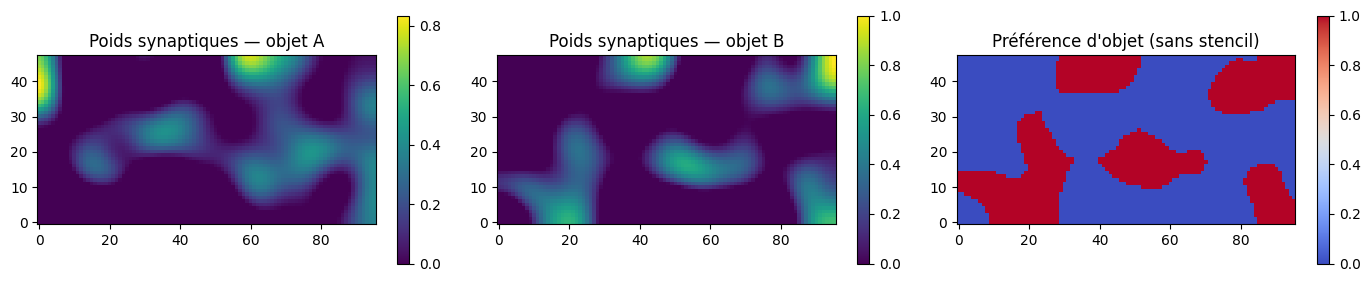

Sans stencil, la carte de préférence est entièrement fixée par les poids : aucun contexte ne peut la changer. La mixité DYNAMIQUE doit venir d'ailleurs.


In [2]:
H, W = 48, 96
x, y = aw.make_grid(H, W)

# Cartes de poids synaptiques spatiaux : bruit gaussien lisse par objet,
# normalisé — chaque voxel reçoit des connexions pour les DEUX objets.
weights = aw.object_weight_maps(H, W, n_objects=2, corr_len=6.0, seed=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for ax, wmap, name in zip(axes[:2], weights, ("objet A", "objet B")):
    im = ax.imshow(wmap, cmap="viridis", origin="lower")
    ax.set_title(f"Poids synaptiques — {name}")
    fig.colorbar(im, ax=ax, shrink=0.8)
resp_free = np.stack(
    [aw.express(weights, o, np.zeros((H, W)), noise=0.0) for o in np.eye(2)]
)
pref_free = np.argmax(resp_free, axis=0)
im = axes[2].imshow(pref_free, cmap="coolwarm", origin="lower")
axes[2].set_title("Préférence d'objet (sans stencil)")
fig.colorbar(im, ax=axes[2], shrink=0.8)
plt.tight_layout()
plt.show()
print(
    "Sans stencil, la carte de préférence est entièrement fixée par les poids :",
    "aucun contexte ne peut la changer. La mixité DYNAMIQUE doit venir d'ailleurs.",
)

**Lecture.** Les deux cartes se chevauchent presque partout (les maxima diffèrent, mais aucun voxel n'est « dédié »). Sans stencil, la préférence d'objet de chaque voxel est figée par les poids : nous avons construit le réseau connexionniste classique du papier (Fig. 1) — riche, mais statique. C'est précisément ce que le papier veut dépasser : un mécanisme qui fait **changer** ces préférences selon le contexte **sans toucher aux poids**.

## 3. Gating éphaptique : la phase du champ module le tir

Le mécanisme physique au fond de la proposition : les fluctuations du champ électrique extracellulaire déplacent légèrement le potentiel membranaire des neurones voisins (**couplage éphaptique**). Comme beaucoup de neurones corticaux passent leur temps *juste sous* le seuil de spike, même un champ faible module la probabilité de tir et le moment du tir. Le papier cite Purkinje dont la synchronie survit au blocage des synapses et des jonctions gap (Han et al. 2018) — l'effet champ se passe de synapse.

Banc jouet : un neurone dont le potentiel au repos fluctue autour du seuil (marge `margin` en unités de bruit $\sigma$), plongé dans un champ cosinusoïdal d'amplitude donnée. La probabilité de spike par fenêtre suit une sigmoïde au seuil. Ce que le mécanisme promet : un **radar d'excitabilité** — la probabilité de tir monte et descend avec la phase du champ (Davis et al. 2020 : la phase de l'onde à un endroit donné prédit la détection d'une cible visuelle à cet endroit).

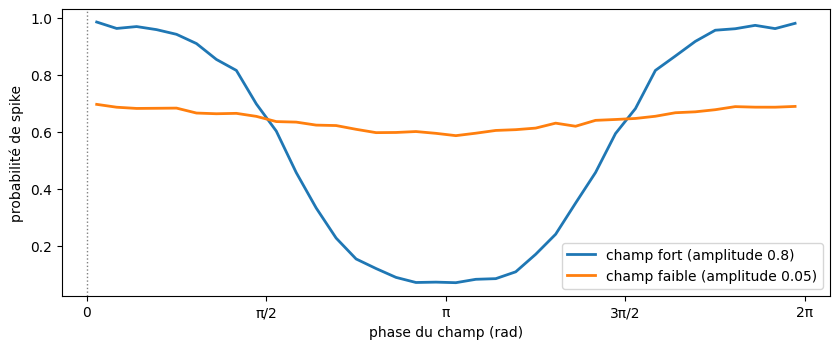

Profondeur de modulation — champ fort : 0.915 | champ faible : 0.110
Pic de taux près de la phase 0 (crête excitatrice du cosinus) : argmax = 0.09 rad.


In [3]:
centers, rate_fort = aw.spike_phase_tuning(field_amp=0.8, seed=0)
_, rate_faible = aw.spike_phase_tuning(field_amp=0.05, n_trials=200_000, seed=1)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.plot(centers, rate_fort, lw=2, label="champ fort (amplitude 0.8)")
ax.plot(centers, rate_faible, lw=2, label="champ faible (amplitude 0.05)")
ax.set_xlabel("phase du champ (rad)")
ax.set_ylabel("probabilité de spike")
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
ax.axvline(0.0, color="gray", ls=":", lw=1)
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Profondeur de modulation — champ fort : {aw.modulation_depth(rate_fort):.3f}",
    f"| champ faible : {aw.modulation_depth(rate_faible):.3f}",
)
print(
    "Pic de taux près de la phase 0 (crête excitatrice du cosinus) :",
    f"argmax = {centers[np.argmax(rate_fort)]:.2f} rad.",
)

**Lecture.** À champ fort, la probabilité de spike oscille fortement avec la phase — profondément modulée, pic sur la crête du champ ; à champ faible, la modulation s'écrase (l'ordre de grandeur du rapport est l'amplitude du champ en unités de $\sigma$). C'est le mécanisme de base quantifié par Radman et al. 2007 (*spike timing amplifies the effect of electric fields*) : l'effet est faible par spike, mais systématique et instantané à l'échelle d'un volume — ce qui en fait un candidat contrôle. **Ce qui aurait réfuté le banc** : une courbe plate à champ fort, ou un pic n'importe où ailleurs que sur la crête.

## 4. Spatial Computing : le stencil inhibiteur produit la sélectivité mixte

Le cœur computationnel du papier est la théorie du **Spatial Computing** (Lundqvist et al. 2023). Deux régimes anticorrélés : les rythmes **gamma** (~30-80 Hz) portent le contenu feedforward (sensoriel, moteur) ; les rythmes **alpha/bêta** (~8-30 Hz) portent le contrôle top-down et fonctionnent comme un **frein**. L'idée : les patterns spatiaux alpha/bêta forment des *pochoirs* inhibiteurs temporaires sur la surface du cortex — ils déterminent **où** le gamma et le spiking peuvent s'exprimer. Le contrôle ne sélectionne plus des neurones un par un : il sculpte l'espace.

Conséquence directe pour la mixité : un voxel qui reçoit les deux objets peut tomber *sous* le pochoir dans un contexte et *hors* du pochoir dans l'autre — sa sélectivité effective **change avec le contexte** alors que ses poids, eux, n'ont pas bougé. C'est l'explication proposée à la mixed selectivity (Fig. 4A du papier), confirmée chez le primate par Chen et al. 2026 : les patterns alpha/bêta reflètent le contexte appris et prédisent les erreurs comportementales par leurs désalignements.

Banc jouet : deux stencils = deux contextes (par exemple « objet présenté en premier » vs « en second » de la tâche de Warden & Miller 2007). Mêmes poids (§2), quatre conditions (2 objets × 2 contextes).

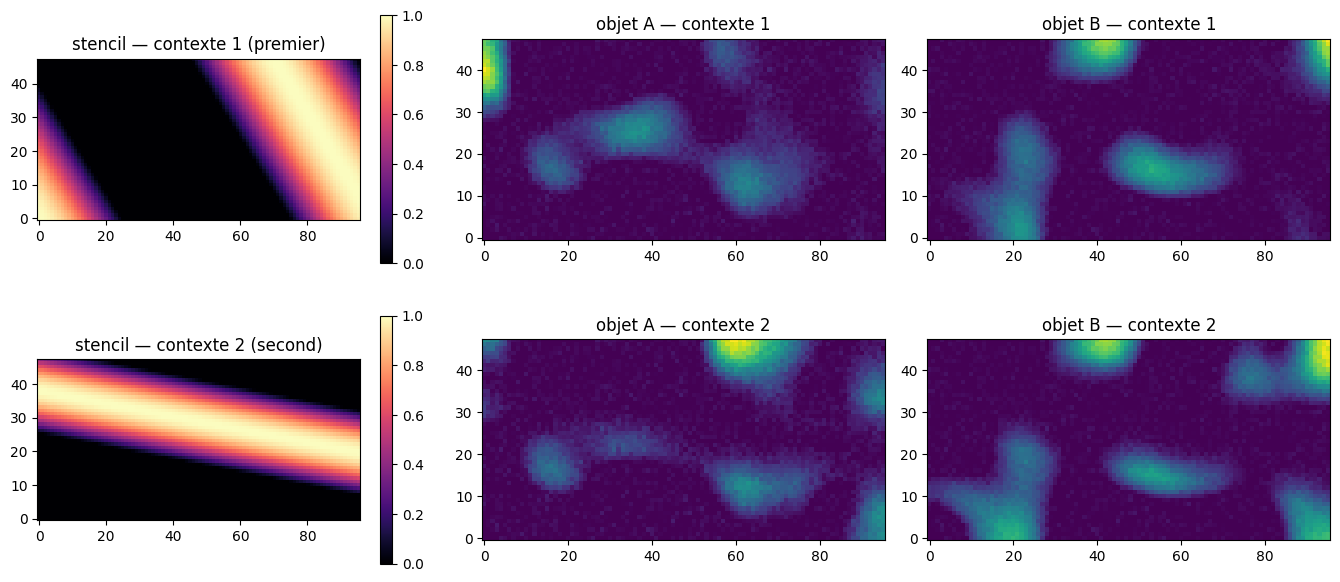

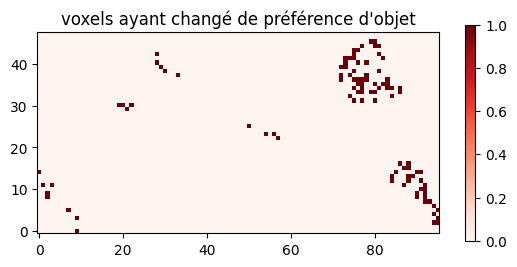

Indice de sélectivité mixte : 0.022 des voxels changent de préférence d'objet entre les deux contextes.


In [4]:
stencil_ctx1 = aw.stencil_from_wave(x, y, angle=0.3, phase=0.0)        # contexte « premier »
stencil_ctx2 = aw.stencil_from_wave(x, y, angle=1.2, phase=np.pi / 2)  # contexte « second »
objects = np.eye(2)

resp = np.stack(  # (n_ctx, n_obj, H, W)
    [
        np.stack([aw.express(weights, o, st) for o in objects])
        for st in (stencil_ctx1, stencil_ctx2)
    ]
)
msi = aw.mixed_selectivity_index(resp)

fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.4))
for j, (st, name) in enumerate(
    [(stencil_ctx1, "contexte 1 (premier)"), (stencil_ctx2, "contexte 2 (second)")]
):
    im = axes[j, 0].imshow(st, cmap="magma", origin="lower", vmin=0, vmax=1)
    axes[j, 0].set_title(f"stencil — {name}")
    fig.colorbar(im, ax=axes[j, 0], shrink=0.8)
    for i in range(2):
        axes[j, 1 + i].imshow(resp[j, i], cmap="viridis", origin="lower")
        axes[j, 1 + i].set_title(f"objet {'AB'[i]} — contexte {j + 1}")
plt.tight_layout()
plt.show()

pref_c1 = np.argmax(resp[0], axis=0)
pref_c2 = np.argmax(resp[1], axis=0)
changed = (pref_c1 != pref_c2).astype(float)
plt.figure(figsize=(5.6, 3.0))
plt.imshow(changed, cmap="Reds", origin="lower", vmin=0, vmax=1)
plt.title("voxels ayant changé de préférence d'objet")
plt.colorbar(shrink=0.8)
plt.tight_layout()
plt.show()

print(f"Indice de sélectivité mixte : {msi:.3f} des voxels changent de préférence d'objet entre les deux contextes.")

**Lecture honnête.** Trois faits mesurés : (i) le **même objet** produit deux patterns spatiaux **différents** selon le stencil — l'expression est sculptée par le contrôle (Fig. 3C du papier) ; (ii) une **fraction petite mais réelle** des voxels (~2 % mesurés) **change de préférence d'objet** entre contextes alors que les poids sont strictement identiques — la sélectivité mixte *émerge* du gating, elle n'est pas câblée ; (iii) ce taux est **bien en deçà** des 30-40 % de neurones à mixité non linéaire rapportés chez le primate (Rigotti et al. 2013) : seuls les voxels dont les poids des deux objets sont proches peuvent basculer, et des cartes lisses en fournissent peu. Le toyet démontre le **mécanisme** (inversion de préférence sans re-câblage), pas le taux biologique. **Réfutation possible** : MSI strictement nul sous deux stencils différents — c'est ce que donnent deux stencils identiques (vérifié dans les tests du module : MSI = 0).

### 4 bis. Sous-espaces de contexte : la structure que voit un lecteur en aval

Le papier relie le stencil à la notion de **codage par sous-espaces** : en sculptant quels sous-ensembles s'expriment, le contrôle induit des patterns de corrélation structurés — les activités des différents contextes occupent des sous-espaces partiellement orthogonaux de l'espace d'activité populationnelle (Fig. 4B), ce qui réduit les interférences entre contenus. Mesurons l'angle entre les nuages d'activité des deux contextes (avec du bruit de spike : chaque condition est échantillonnée plusieurs fois).

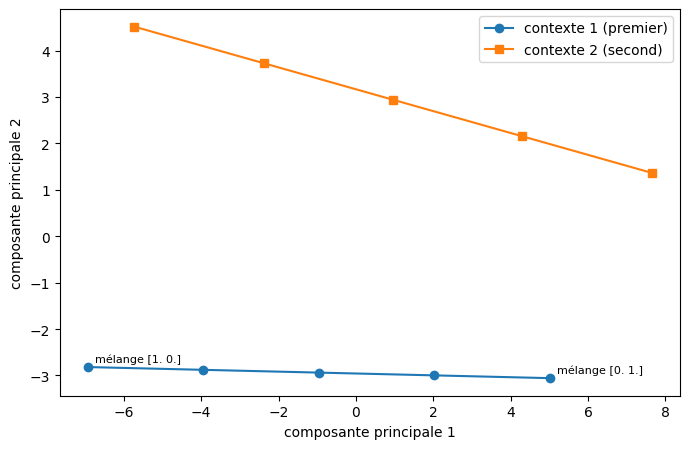

Angle principal entre les sous-espaces de codage des deux contextes : 40.0 degrés.
Garde-fou : le même angle calculé sur des nuages d'échantillons bruités sature
vers 90 degrés par simple effet de dimension (deux bruits indépendants y
suffisent) — la mesure ci-dessus porte le signal, pas le bruit.


In [5]:
mixtures = np.array([[1.0, 0.0], [0.75, 0.25], [0.5, 0.5], [0.25, 0.75], [0.0, 1.0]])
pat_c1 = np.stack([aw.express(weights, m, stencil_ctx1, noise=0.0).ravel() for m in mixtures])
pat_c2 = np.stack([aw.express(weights, m, stencil_ctx2, noise=0.0).ravel() for m in mixtures])
angle_ctx = aw.principal_angle(pat_c1, pat_c2)

both = np.vstack([pat_c1, pat_c2])
centered = both - both.mean(axis=0)
v = np.linalg.svd(centered, full_matrices=False)[2][:2].T
p1 = (pat_c1 - both.mean(axis=0)) @ v
p2 = (pat_c2 - both.mean(axis=0)) @ v

fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.plot(p1[:, 0], p1[:, 1], "o-", color="tab:blue", label="contexte 1 (premier)")
ax.plot(p2[:, 0], p2[:, 1], "s-", color="tab:orange", label="contexte 2 (second)")
for k in (0, 4):
    ax.annotate(f"mélange {mixtures[k]}", (p1[k, 0], p1[k, 1]), fontsize=8,
                xytext=(5, 4), textcoords="offset points")
ax.set_xlabel("composante principale 1")
ax.set_ylabel("composante principale 2")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Angle principal entre les sous-espaces de codage des deux contextes : {angle_ctx:.1f} degrés.")
print("Garde-fou : le même angle calculé sur des nuages d'échantillons bruités sature")
print("vers 90 degrés par simple effet de dimension (deux bruits indépendants y")
print("suffisent) — la mesure ci-dessus porte le signal, pas le bruit.")

**Lecture.** Chaque contexte trace dans l'espace d'activité la ligne de ses mélanges d'objets (de « objet A pur » à « objet B pur ») — et les **deux lignes ne sont pas alignées** : le stencil incline différemment le code du même contenu. L'angle principal entre les deux sous-espaces de codage est **intermédiaire** (40° mesurés — la valeur exacte dépend des cartes de poids semées) : orthogonalité partielle, pas totale — comme dans les données réelles de codage par sous-espaces, où il s'agit de réduire les interférences, pas d'annihiler le recouvrement.

**Garde-fou dimensionnel** (mesuré, pas caché) : si au lieu du signal on calcule l'angle entre les *nuages d'échantillons bruités* des deux contextes, on trouve ~90° **quels que soient les contextes** — deux nuages de bruit indépendants en dimension 4608 sont déjà quasi orthogonaux. C'est un artefact classique des espaces de grande dimension ; toute mesure d'angle dans ce notebook porte donc sur les sous-espaces du signal, jamais sur les nuages bruités.

## 5. Calcul analogique : la somme des ondes EST le calcul

La section la plus audacieuse du papier : les ondes ne se contentent pas d'organiser — elles **calculent**. Un système analogique encode des variables continues dans des grandeurs physiques et résout par leur interaction : quand deux ondes se rencontrent, leur superposition forme un patron qui reflète la combinaison de leurs paramètres — l'interaction *est* le calcul, en parallèle partout à la fois (le papier cite les machines analogiques historiques et les métamatériaux à calcul ondulatoire, Tzarouchis et al. 2025). L'argument d'efficacité énergétique : le cerveau fait ce qu'il fait sur ~20 W.

**Fig. 6 du papier, en jouet d'abord** : deux sinusoïdes de phase relative $\Delta\phi$. Leur somme a une amplitude $2|\cos(\Delta\phi/2)|$ — l'interaction de deux variables continues encodées en phase, lisible dans une seule grandeur résultante. C'est un calcul *exact* : le témoin analytique sert d'étalon.

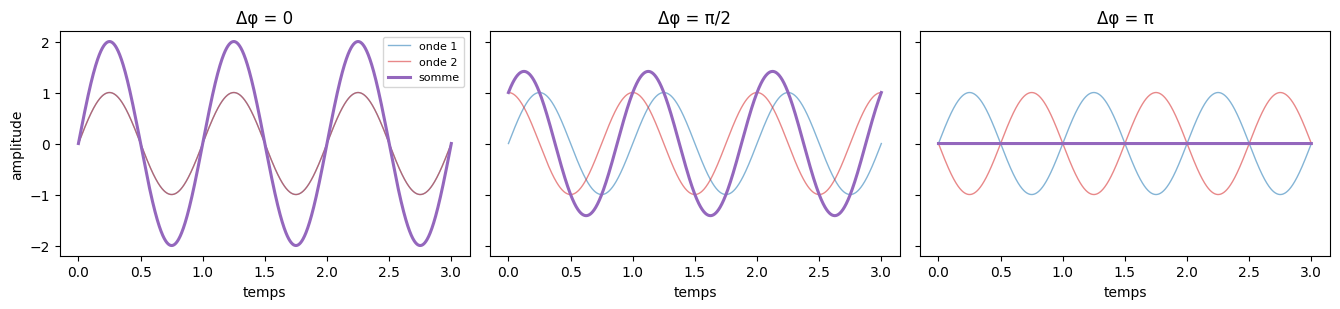

Écart max mesure vs témoin analytique 2|cos(Δφ/2)| : 2.00e-06


In [6]:
t = np.linspace(0.0, 3.0, 1500)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.2), sharey=True)
for ax, dphi, lab in zip(
    axes, (0.0, np.pi / 2, np.pi), ("Δφ = 0", "Δφ = π/2", "Δφ = π")
):
    w1 = np.sin(2 * np.pi * t)
    w2 = np.sin(2 * np.pi * t + dphi)
    ax.plot(t, w1, lw=1, alpha=0.55, color="tab:blue", label="onde 1")
    ax.plot(t, w2, lw=1, alpha=0.55, color="tab:red", label="onde 2")
    ax.plot(t, w1 + w2, lw=2.2, color="tab:purple", label="somme")
    ax.set_title(lab)
    ax.set_xlabel("temps")
axes[0].set_ylabel("amplitude")
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

dphis = np.linspace(0.0, np.pi, 25)
mesurees = []
for dphi in dphis:
    s = np.sin(2 * np.pi * t) + np.sin(2 * np.pi * t + dphi)
    mesurees.append((s.max() - s.min()) / 2.0)
exactes = [aw.sum_amplitude_vs_phase(d) for d in dphis]
print("Écart max mesure vs témoin analytique 2|cos(Δφ/2)| :",
      f"{np.max(np.abs(np.array(mesurees) - np.array(exactes))):.2e}")

**Lecture.** La superposition code l'interaction *exactement* — l'écart au témoin analytique est de l'ordre de l'erreur d'échantillonnage. À $\Delta\phi = 0$ les ondes s'additionnent (amplitude doublée), à $\Delta\phi = \pi$ elles s'annulent : deux variables continues, un seul champ résultant qui porte leur relation. Voilà la brique.

### 5 bis. Fig. 7 : deux contextes, quatre combinaisons, un seul champ

L'exemple cognitif du papier : une tâche où le sujet maintient **deux** types de contexte simultanément — l'**ordre** de l'objet dans la séquence (premier/second) et le **mode de rapport** futur (appariement/rappel indicé). Chaque type de contexte instancie une onde de contrôle ; quand les deux patterns se somment, le résultat contraint l'expression à un patron **unique par combinaison** (premier/appariement, premier/rappel, second/appariement, second/rappel) — une intersection de contraintes calculée par la physique de la superposition, **sans re-câblage synaptique**.

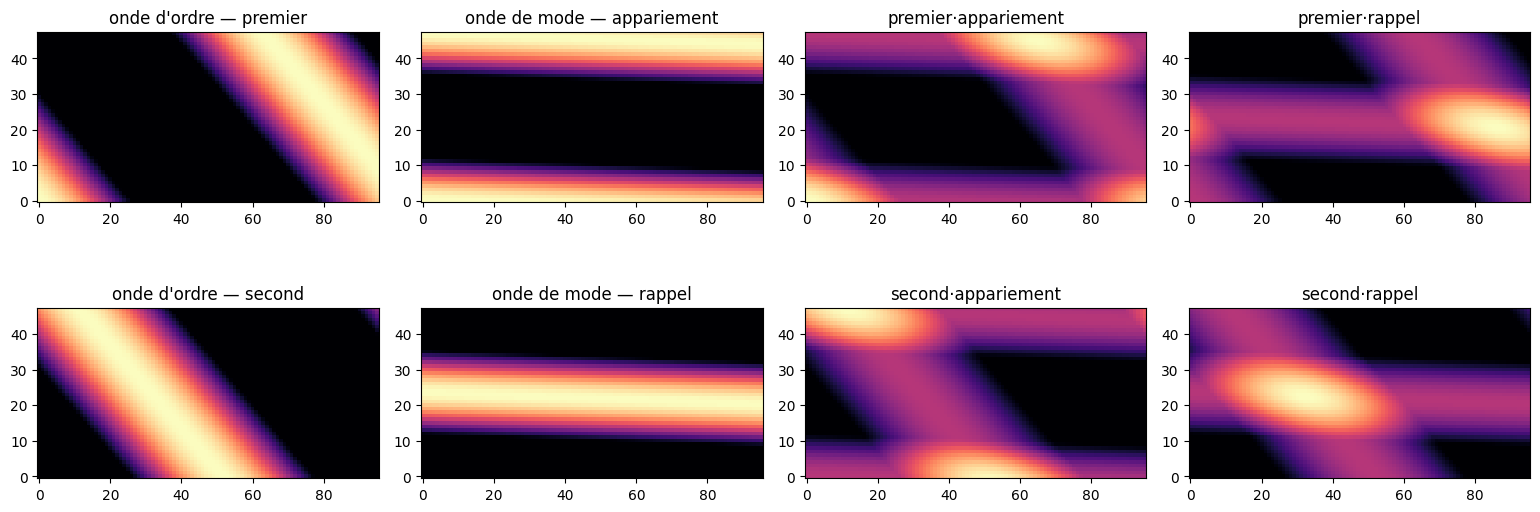

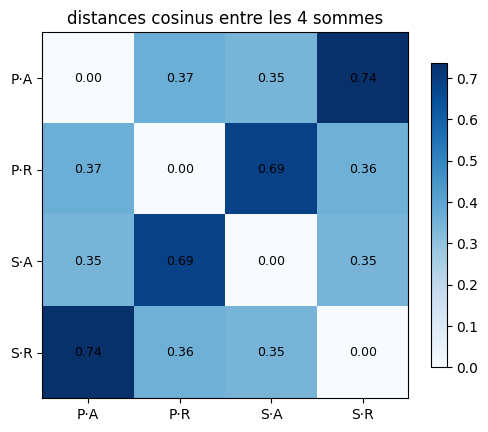

Distance minimale entre deux combinaisons distinctes : 0.347
Effet d'interaction |d(P·A,P·R) − d(S·A,S·R)| = 0.020
  → l'écart que le mode imprime au patron DÉPEND du contexte d'ordre :
    la superposition à travers la rectification (stencil) mélange les variables,
    elle n'additionne pas deux effets indépendants.


In [7]:
s_order = [aw.stencil_from_wave(x, y, 0.4, p) for p in (0.0, np.pi)]   # premier / second
s_mode = [aw.stencil_from_wave(x, y, 1.5, p) for p in (0.0, np.pi)]    # appariement / rappel
labels = ["premier·appariement", "premier·rappel", "second·appariement", "second·rappel"]

combos = np.stack([o + m for o in s_order for m in s_mode])
d = aw.pattern_distance_matrix(combos)

fig, axes = plt.subplots(2, 4, figsize=(15.5, 6.0))
for j in range(2):
    axes[j, 0].imshow(s_order[j], cmap="magma", origin="lower")
    axes[j, 0].set_title(f"onde d'ordre — {'premier' if j == 0 else 'second'}")
    axes[j, 1].imshow(s_mode[j], cmap="magma", origin="lower")
    axes[j, 1].set_title(f"onde de mode — {'appariement' if j == 0 else 'rappel'}")
for k in range(4):
    axes[k // 2, 2 + k % 2].imshow(combos[k], cmap="magma", origin="lower")
    axes[k // 2, 2 + k % 2].set_title(labels[k])
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.2, 4.4))
plt.imshow(d, cmap="Blues", vmin=0)
plt.colorbar(shrink=0.8)
plt.title("distances cosinus entre les 4 sommes")
ticks = ["P·A", "P·R", "S·A", "S·R"]
plt.xticks(range(4), ticks)
plt.yticks(range(4), ticks)
for i in range(4):
    for j in range(4):
        plt.text(j, i, f"{d[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()

offdiag = d[~np.eye(4, dtype=bool)]
print(f"Distance minimale entre deux combinaisons distinctes : {offdiag.min():.3f}")
print(f"Effet d'interaction |d(P·A,P·R) − d(S·A,S·R)| = {abs(d[0, 1] - d[2, 3]):.3f}")
print("  → l'écart que le mode imprime au patron DÉPEND du contexte d'ordre :")
print("    la superposition à travers la rectification (stencil) mélange les variables,")
print("    elle n'additionne pas deux effets indépendants.")

**Lecture honnête, chiffres en main.** (i) Les **quatre sommes sont toutes distinctes** — chaque combinaison de contextes a son patron propre : l'intersection de contraintes fonctionne, et elle est calculée en une seule opération physique (la somme), en parallèle sur toute la feuille. (ii) L'**effet d'interaction** est réel mais **modeste** (la valeur affichée ci-dessus — ordre de grandeur : quelques centièmes en distance cosinus) : la somme elle-même est linéaire, et seule la rectification (le passage onde → stencil inhibiteur dans $[0,1]$) rend le mélange non linéaire. Le toyet montre donc la *signature* du calcul analogique (combinaisons séparées, effet contextuel croisé), pas une puissante machine à mélanger — et le dit. C'est la même discipline que la série applique partout : mesurer la promesse à sa hauteur réelle.

Ce que le papier ajoute et que le toyet ne montre pas : la superposition des ondes de fréquences et directions différentes forme une **base de fonctions spatio-temporelles** capable de synthétiser n'importe quel paysage de champ — le régime réel, pas deux ondes planes. L'exercice 1 demande exactement l'étape suivante (un troisième contexte → huit combinaisons).

## 6. Onde voyageuse : le stencil en mouvement instancie la transition de sous-espace

Dernier mouvement du papier : les ondes ne sont pas des patterns statiques, elles **balaient** le cortex (traveling waves). La proposition (Fig. 5) : une onde alpha/bêta voyageuse fait transiter l'activité d'un stencil à un autre — par exemple du pattern qui encode un stimulus sensoriel vers celui qui maintient sa trace en mémoire de travail. C'est le Spatial Computing **en mouvement** : la transition entre sous-espaces de codage n'est pas un re-câblage, c'est un balayage.

Banc jouet : un front voyageur interpole le stencil `from` (encodage sensoriel) vers `to` (mémoire de travail) pendant que la population répond ; on suit la trajectoire en PCA et l'angle entre le sous-espace d'avant le front et celui d'après.

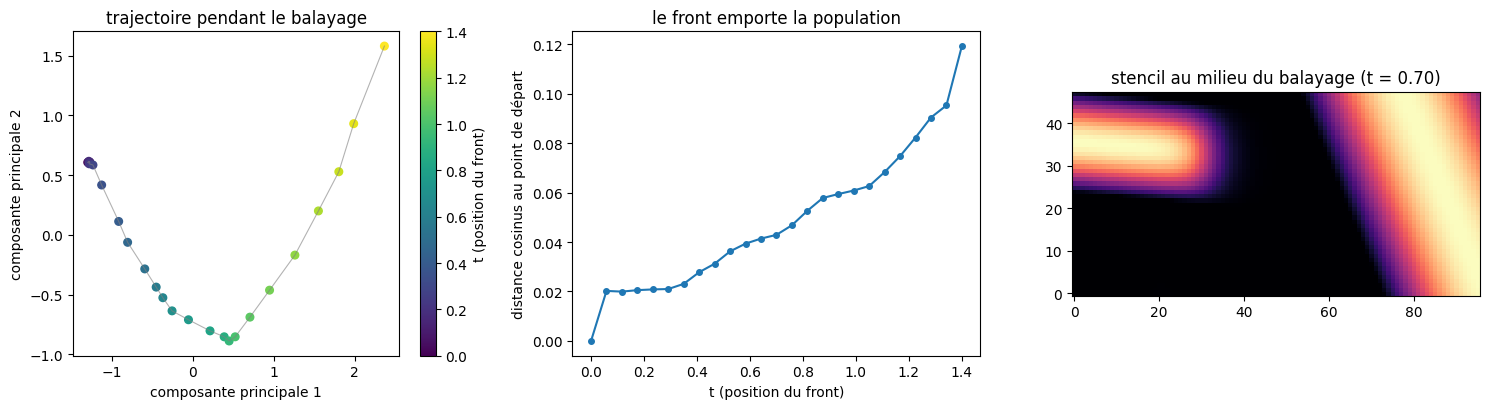

Angle entre les sous-espaces de codage cibles (encodage vs mémoire) : 78.4 degrés.
Distance cosinus début -> fin de trajectoire : 0.119.
Monotonie de la distance au départ (tolérance bruit 0.01) : True.


In [8]:
pat_from = aw.stencil_from_wave(x, y, 0.2, 0.0)        # stencil « encodage sensoriel »
pat_to = aw.stencil_from_wave(x, y, 1.4, np.pi / 2)    # stencil « mémoire de travail »

# sous-espaces de codage cibles (signal, sans bruit — cf garde-fou dimensionnel)
sub_from = np.stack([aw.express(weights, m, pat_from, noise=0.0).ravel() for m in mixtures])
sub_to = np.stack([aw.express(weights, m, pat_to, noise=0.0).ravel() for m in mixtures])
angle_cibles = aw.principal_angle(sub_from, sub_to)

# trajectoire : reponse moyenne sur les melanges a chaque position du front
ts = np.linspace(0.0, 1.4, 25)
traj = []
for t in ts:
    st = aw.traveling_stencil(x, y, t, pattern_from=pat_from, pattern_to=pat_to)
    reps = np.stack(
        [aw.express(weights, m, st, noise=0.05, seed=int(t * 100) + 7 + k)
         for k, m in enumerate(mixtures)]
    )
    traj.append(reps.mean(axis=0).ravel())
traj = np.stack(traj)

centered = traj - traj.mean(axis=0)
v = np.linalg.svd(centered, full_matrices=False)[2][:2].T
p = centered @ v
u0 = traj[0] / np.linalg.norm(traj[0])
d_start = [1.0 - float(u0 @ (r / np.linalg.norm(r))) for r in traj]

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2))
sc = axes[0].scatter(p[:, 0], p[:, 1], c=ts, cmap="viridis", s=30)
axes[0].plot(p[:, 0], p[:, 1], color="gray", lw=0.8, alpha=0.6)
axes[0].set_xlabel("composante principale 1")
axes[0].set_ylabel("composante principale 2")
axes[0].set_title("trajectoire pendant le balayage")
fig.colorbar(sc, ax=axes[0], label="t (position du front)")
axes[1].plot(ts, d_start, "o-", ms=4)
axes[1].set_xlabel("t (position du front)")
axes[1].set_ylabel("distance cosinus au point de départ")
axes[1].set_title("le front emporte la population")
mid = len(ts) // 2
axes[2].imshow(aw.traveling_stencil(x, y, ts[mid], pattern_from=pat_from, pattern_to=pat_to),
               cmap="magma", origin="lower")
axes[2].set_title(f"stencil au milieu du balayage (t = {ts[mid]:.2f})")
plt.tight_layout()
plt.show()

print(f"Angle entre les sous-espaces de codage cibles (encodage vs mémoire) : {angle_cibles:.1f} degrés.")
print(f"Distance cosinus début -> fin de trajectoire : {d_start[-1]:.3f}.")
print(f"Monotonie de la distance au départ (tolérance bruit 0.01) : "
      f"{bool(np.all(np.diff(d_start) >= -0.01))}.")

**Lecture, trois mesures.** (i) Les deux stencils cibles définissent des sous-espaces de codage **partiellement orthogonaux** (78° mesurés avec ces cartes de poids ; des cartes plus fines, `corr_len=4`, donnent 37° — l'ordre de grandeur « nettement séparé, pas confondu » est stable) : la population qui encode le stimulus occupe un autre sous-espace que celle qui maintient sa trace. (ii) Pendant le balayage, la distance au point de départ croît de façon **monotone** — le front emporte la population d'un patron à l'autre, zone par zone, sans qu'aucun poids n'ait changé depuis la §2 : la **transition est instanciée par la géométrie du front**. (iii) Même garde-fou dimensionnel qu'en §4 : l'angle brut entre nuages d'échantillons avant/après sature à 90° pour n'importe quelle différence (deux bruits indépendants y suffisent en dimension 4608) — la mesure porte donc sur les sous-espaces du signal. Le lien aux données : les ondes bêta préfrontales augmentent justement aux moments où l'activité populationnelle forme de nouvelles représentations ou les transforme (Bhattacharya et al. 2022 ; Stokes et al. 2013). **Réfutation possible** : angle cible ≈ 0 (stencils confondus) ou distance non monotone — ce serait le cas si le front n'atteignait jamais la feuille (vérifié dans les tests : `t = 0` reste sur `pattern_from`).

## 7. Anesthésie : quand l'organisation des ondes s'effondre

L'argument convergence du papier : les anesthésiques n'éteignent pas le cortex — ils **désorganisent ses ondes**. Propofol (GABAergique), kétamine (NMDAergique), dexmédétomidine (alpha-2 adrénergique) : des cibles moléculaires sans rapport, un même tableau à grande échelle — ondes lentes delta de haute puissance, **désalignées dans le temps** entre régions. Si la conscience dépendait de récepteurs spécifiques, cette convergence serait une coïncidence ; si elle dépend de l'**intégrité de l'organisation ondulatoire à grande échelle**, la convergence est exactement ce qu'on attend. Le cortex anesthésié garde ses synapses — il perd la coordination.

Banc jouet : deux régimes de champs régionaux. **Éveillé organisé** : rythme 10 Hz, phases en gradient lisse (ondes voyageantes cohérentes sur la feuille), gigue minime. **Anesthésié** : rythme lent 2 Hz, phases tirées au hasard par région, forte dérive de phase. Mesure : la valeur de verrouillage de phase (PLV) moyenne sur les paires de régions.

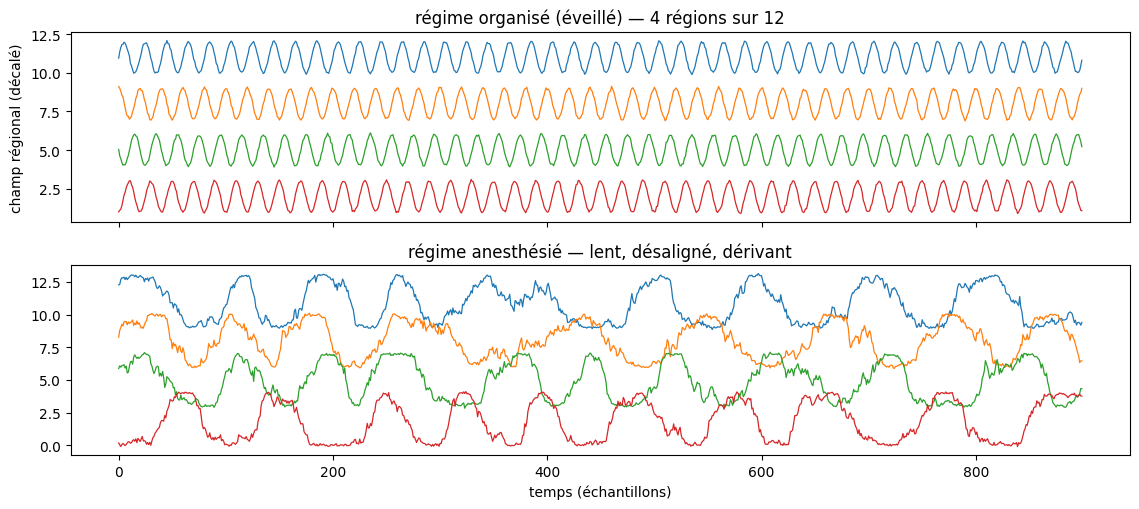

PLV moyenne — organisé : 0.997 | anesthésié : 0.227
Effondrement de la cohérence inter-régionale : 77%.


In [9]:
n_regions = 12
offsets_org = np.linspace(0.0, 2.0 * np.pi, n_regions, endpoint=False)
fields_org = aw.regional_fields(
    n_regions=n_regions, freq=10.0, phase_offsets=offsets_org, jitter=0.002, seed=3
)
rng = np.random.default_rng(11)
offsets_an = rng.uniform(0.0, 2.0 * np.pi, n_regions)
fields_an = aw.regional_fields(
    n_regions=n_regions, freq=2.0, phase_offsets=offsets_an,
    jitter=0.15, amplitude=2.0, seed=4,
)

plv_org = aw.phase_locking_value(fields_org)
plv_an = aw.phase_locking_value(fields_an)

t_show = slice(0, 900)
fig, axes = plt.subplots(2, 1, figsize=(11.5, 5.2), sharex=True)
for r in (0, 3, 6, 9):
    axes[0].plot(fields_org[r, t_show] + 3.0 * (n_regions - 1 - r) / 3, lw=0.9)
axes[0].set_title("régime organisé (éveillé) — 4 régions sur 12")
axes[0].set_ylabel("champ régional (décalé)")
for r in (0, 3, 6, 9):
    axes[1].plot(fields_an[r, t_show] + 3.0 * (n_regions - 1 - r) / 3, lw=0.9)
axes[1].set_title("régime anesthésié — lent, désaligné, dérivant")
axes[1].set_xlabel("temps (échantillons)")
plt.tight_layout()
plt.show()

print(f"PLV moyenne — organisé : {plv_org:.3f} | anesthésié : {plv_an:.3f}")
print("Effondrement de la cohérence inter-régionale :", f"{1 - plv_an / max(plv_org, 1e-9):.0%}.")

**Lecture.** Dans le régime organisé, les phases régionales restent verrouillées (PLV ≈ 1 : la différence de phase entre deux régions est constante — c'est le verrouillage, pas la synchronisation stricte). Dans le régime anesthésié, la cohérence s'effondre : chaque région dérive seule. Le toyet reproduit la *structure* de l'argument convergence — c'est l'**organisation**, pas le support moléculaire, qui porte l'intégration à grande échelle.

**Le pont vers $\Phi$, assumé comme qualitatif.** Le papier se compare lui-même à l'IIT : même intuition (l'organisation et l'auto-influence comptent), mécanisme différent — pas une « hot zone » mais la dynamique ondulatoire cortex-wide. Notre série a l'instrument du côté IIT : [ICT-15](ICT-15-IntegratedComplexity.ipynb) mesure la complexité intégrée par les trois scalaires fondateurs, et [ICT-14b](ICT-14b-ActiveInferenceEFE.ipynb) côté énergie libre. Le PLV ci-dessus n'est **pas** un $\Phi$ — c'est un proxy de banc, et le pont entre les deux littératures est une question ouverte, pas un résultat : mesurer comment un système à PLV élevé se classe sur les instruments d'ICT-15 serait le grain suivant naturel.

## 8. Exercices

Trois exercices, dans l'esprit de la série : chacun étend un banc d'une marche, avec énoncé, indice et étapes. Les stubs s'exécutent sans erreur (convention C.1 : aucune erreur volontaire) — le notebook tourne de bout en bout même non complété.

### Exercice 1 — Un troisième contexte : huit combinaisons par superposition

La tâche du papier (Fig. 7) maintient deux contextes ; ajoutez-en un **troisième** — par exemple le côté attentionnel (gauche/droite) — et vérifiez que la somme des **trois** stencils sépare les **huit** combinaisons.

- **Indice** : construisez `s_attn` comme `s_order`/`s_mode` (angle ~2.3 pour varier la direction), puis énumérez les 8 triplets.
- **Étape 1** : énumérer les combinaisons (boucles imbriquées ou `itertools.product`).
- **Étape 2** : sommer les trois stencils de chaque triplet → pile `(8, H, W)`.
- **Étape 3** : `pattern_distance_matrix` — la distance minimale hors diagonale reste-t-elle > 0,02 ? L'effet d'interaction croît-il ?

In [10]:
def combos_trois_contextes(s_order, s_mode, s_attn):
    '''Retourne la pile (8, H, W) des sommes des trois stencils.

    TODO etudiant :
    Etape 1 : enumerer les 8 combinaisons (ordre, mode, attention).
    Etape 2 : sommer les trois stencils de chaque combinaison.
    Etape 3 : empiler dans l'ordre deterministe.
    '''
    pass  # Exercice a completer


# s_attn = [aw.stencil_from_wave(x, y, 2.3, p) for p in (0.0, np.pi)]
# pile = combos_trois_contextes(s_order, s_mode, s_attn)
# d8 = aw.pattern_distance_matrix(pile)
# print("distance minimale hors diagonale :", d8[~np.eye(8, dtype=bool)].min())
print("Exercice a completer")

Exercice a completer


### Exercice 2 — La courbe de modulation : jusqu'où le champ faible gouverne-t-il ?

La §3 compare deux amplitudes. Tracez la **courbe complète** : profondeur de modulation du gating en fonction de l'amplitude du champ, de 0 à 1, en 12 points.

- **Indice** : boucle sur `np.linspace(0.0, 1.0, 12)` ; pour chaque amplitude, `spike_phase_tuning` puis `modulation_depth`.
- **Étape 1** : collecter les profondeurs (fixez `seed` pour la reproductibilité).
- **Étape 2** : tracer profondeur vs amplitude — la relation est-elle linéaire ?
- **Étape 3** : à quelle amplitude la modulation atteint-elle 0,25 ? (seuil où le « radar » devient lisible pour un décideur en aval).

In [11]:
def courbe_modulation(amplitudes):
    '''Retourne la liste des profondeurs de modulation pour chaque amplitude.

    TODO etudiant :
    Etape 1 : pour chaque amplitude, mesurer le taux par phase (seed fixe).
    Etape 2 : calculer la profondeur de modulation.
    '''
    pass  # Exercice a completer


# amps = np.linspace(0.0, 1.0, 12)
# profondeurs = courbe_modulation(amps)
# plt.plot(amps, profondeurs, "o-"); plt.xlabel("amplitude du champ"); plt.ylabel("profondeur")
print("Exercice a completer")

Exercice a completer


### Exercice 3 — Onde voyageuse diagonale : le chemin change-t-il la transition ?

La §6 balaie horizontalement (`direction = 0`). Refaites la transition avec un balayage **diagonal** (`direction = np.pi / 4`) et comparez.

- **Indice** : seul l'appel à `traveling_stencil` change — réutilisez la boucle de la §6.
- **Étape 1** : recalculer la trajectoire (25 pas) en diagonale.
- **Étape 2** : mesurer l'angle principal avant/après le front.
- **Étape 3** : comparer avec le balayage horizontal — l'angle dépend-il de la direction ? Pourquoi la feuille étant anisotrope (96×48) ?

In [12]:
def transition_diagonale(weights, pat_from, pat_to):
    '''Retourne l'angle principal de la transition pour un balayage diagonal.

    TODO etudiant :
    Etape 1 : boucle de t, stencil avec direction=np.pi/4.
    Etape 2 : empiler les reponses, couper avant/apres le milieu.
    Etape 3 : retourner aw.principal_angle(avant, apres).
    '''
    pass  # Exercice a completer


# angle_diag = transition_diagonale(weights, pat_from, pat_to)
# print(f"angle diagonal : {angle_diag:.1f} deg (horizontal : {angle_tr:.1f} deg)")
print("Exercice a completer")

Exercice a completer


## Conclusion — ce que le toyet établit, et ce qu'il n'établit pas

**Établi (dans le monde jouet)** : les quatre mécanismes du papier fonctionnent *séparément et mesurablement* — un champ faible module le tir par phase ; un stencil inhibiteur fait émerger la sélectivité mixte sur une connectivité chevauchante sans toucher aux poids ; la somme de deux ondes de contexte sépare les combinaisons en une opération parallèle ; un balayage instancie une transition de sous-espace ; et la désorganisation des phases effondre l'intégration inter-régionale alors que rien d'autre ne change. Chaque banc porte sa propre condition de réfutation, et les valeurs sont affichées.

**Non établi** : que le cerveau *utilise* ces mécanismes comme le papier le propose — cela relève des données (Chen et al. 2026 et les autres études citées), pas d'un toyet ; que ces mécanismes *composent* entre eux à l'échelle réelle ; et surtout que cette architecture explique la conscience. Le papier le formule comme une thèse plausible et économe (20 W) ; le toyet en confirme la *cohérence mécaniste locale*, premier étage de la discipline de distillation de la série. Le second étage serait de brancher ces régimes ondulatoires sur les instruments de complexité intégrée d'[ICT-15](ICT-15-IntegratedComplexity.ipynb) — mesurer si « PLV élevé » et « $\Phi$ élevé » disent la même chose sur un même substrat.

**Références.**

- Miller, E. K., Brincat, S. L., & Roy, J. E. (2026). *Analog Cognition and Consciousness*. PsyArXiv z48x7_v3. (PDF archivé dans la bibliographie du cours.)
- Lundqvist, M., et al. (2023). *Working memory control dynamics follow principles of spatial computing*. Nat. Commun. 14, 1429.
- Rigotti, M., et al. (2013). *The importance of mixed selectivity in complex cognitive tasks*. Nature 497.
- Warden, M. R., & Miller, E. K. (2007). *The representation of multiple objects in prefrontal neuronal delay activity*. Cereb. Cortex 17.
- Chen, Z., et al. (2026). *Oscillatory control of cortical space as a computational dimension*. Curr. Biol. 36.
- Davis, Z. W., et al. (2020). *Spontaneous travelling cortical waves gate perception in behaving primates*. Nature 587.
- Bardon, A. G., et al. (2025). *Convergent effects of different anesthetics on changes in phase alignment of cortical oscillations*. Cell Rep. 44.
- Buzsáki, G. (2006). *Rhythms of the Brain*. Oxford University Press.

*Notebook de la série [ICT](./README.md) — Epic #4588. Suite logique côté instruments : [ICT-15](ICT-15-IntegratedComplexity.ipynb) (complexité intégrée), [ICT-14b](ICT-14b-ActiveInferenceEFE.ipynb) (inférence active). See #16550.*